# Laboratorium 4: Funkcje sklejane

## 1. Wstęp i definicja problemu
Celem niniejszego laboratorium jest wyznaczenie interpolacyjnej funkcji sklejanej drugiego oraz trzeciego stopnia dla zadanej funkcji analitycznej. Dodatkowo przeprowadzona zostanie analiza wpływu wyboru różnych warunków brzegowych oraz liczby przedziałów na dokładność interpolacji.

Badana funkcja oraz jej pierwsza pochodna analityczna (wykorzystywana w warunkach brzegowych):
$$f(x) = 10 + 0.5x^2 - 10\cos(2x)$$
$$f'(x) = x + 20\sin(2x)$$

Zakładany przedział interpolacji to $x \in [-3\pi, 3\pi]$.

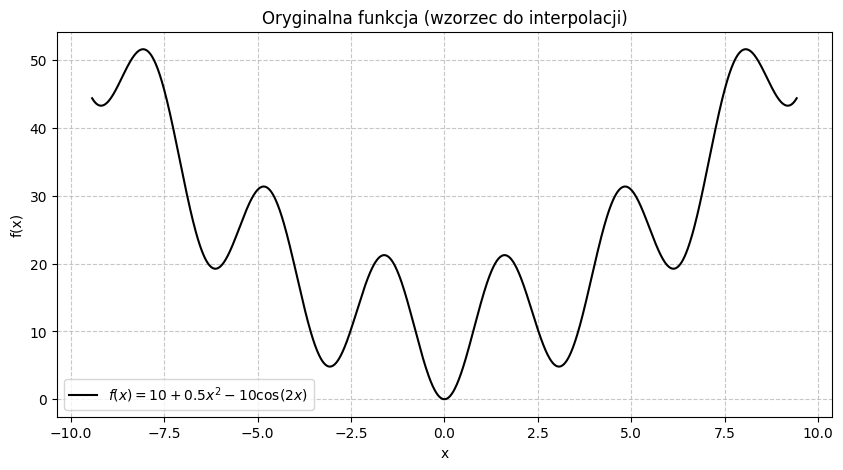

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from typing import Union

# Typ dla zmiennych, które mogą być pojedynczą liczbą lub tablicą numpy
Numeric = Union[float, np.ndarray]

def f(x: Numeric) -> Numeric:
    """Zwraca wartość badanej funkcji."""
    return 10.0 + 0.5 * x**2 - 10.0 * np.cos(2.0 * x)

def df(x: Numeric) -> Numeric:
    """Zwraca wartość pierwszej pochodnej funkcji f(x)."""
    return x + 20.0 * np.sin(2.0 * x)

# Parametry globalne
a: float = -3.0 * np.pi
b: float = 3.0 * np.pi
points_count: int = 1000

# Gęsta siatka dla idealnego wykresu
x_dense: np.ndarray = np.linspace(a, b, points_count)
y_true: np.ndarray = f(x_dense)

# Wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(x_dense, y_true, label=r"$f(x) = 10 + 0.5x^2 - 10\cos(2x)$", color='black', linewidth=1.5)
plt.title("Oryginalna funkcja (wzorzec do interpolacji)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 2. Teoria i warunki brzegowe

### Funkcje sklejane 3. stopnia (Sześcienne / Cubic)
Dla przedziału $[a, b]$ podzielonego na $n-1$ podprzedziałów przez $n$ węzłów $x_1 < x_2 < \dots < x_n$, funkcja sklejana 3. stopnia $s(x)$ składa się z wielomianów sześciennych $s_i(x)$ na każdym z przedziałów $[x_i, x_{i+1}]$. Wymagamy, aby globalna funkcja $s(x)$ należała do klasy $C^2[a,b]$, co oznacza bezwzględną ciągłość samej funkcji, jej pierwszej oraz drugiej pochodnej we wszystkich węzłach wewnętrznych.

Aby uniknąć trudności obliczeniowych przy bezpośrednim wyznaczaniu 4 współczynników wielomianu dla każdego przedziału, stosuje się następujące podejście:
1. Ponieważ $s_i(x)$ jest wielomianem 3. stopnia, to jego druga pochodna $s_i''(x)$ musi być funkcją liniową. Przyjmując szerokość przedziału jako $h_i = x_{i+1} - x_i$, drugą pochodną można wyrazić jako:
   $$s_i''(x) = s_i''(x_i)\frac{x_{i+1}-x}{h_i} + s_i''(x_{i+1})\frac{x-x_i}{h_i}$$
2. Całkując to równanie dwukrotnie i wykorzystując warunki interpolacji $s_i(x_i) = y_i$ oraz $s_i(x_{i+1}) = y_{i+1}$, wyliczamy stałe całkowania, uzyskując wzór na samo $s_i(x)$.
3. Aby zagwarantować gładkość krzywej, przyrównuje się pierwsze pochodne w węzłach wewnętrznych: $s_{i-1}'(x_i) = s_i'(x_i)$. Wprowadzając dla przejrzystości zmienne pomocnicze: $\sigma_i = \frac{1}{6}s''(x_i)$ oraz $\Delta_i = \frac{y_{i+1}-y_i}{h_i}$, otrzymuje się ostatecznie układ $(n-2)$ równań:
   $$h_{i-1}\sigma_{i-1} + 2(h_{i-1}+h_i)\sigma_i + h_i\sigma_{i+1} = \Delta_i - \Delta_{i-1} \quad \text{dla } i = 2, 3, \dots, n-1$$

Do rozwiązania układu dla $n$ niewiadomych $\sigma_i$ brakuje dwóch równań, które stanowią warunki brzegowe:
1. **WB1 (Naturalny):** Zakłada się, że druga pochodna na skrajnych węzłach wynosi zero: $s''(x_1) = 0 \implies \sigma_1 = 0$ oraz $s''(x_n) = 0 \implies \sigma_n = 0$.
2. **WB2 (Utwierdzony / Clamped):** Narzuca się dokładną wartość pierwszej pochodnej na skrajnych węzłach: $s'(x_1) = f'(x_1)$ oraz $s'(x_n) = f'(x_n)$, włączając te zależności do pierwszego i ostatniego równania układu.

---

### Funkcje sklejane 2. stopnia (Kwadratowe / Quadratic)
Dla interpolacji kwadratowej na każdym przedziale definiuje się funkcję:
$$s_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2$$
Dla $n-1$ przedziałów generuje to układ $3n - 3$ niewiadomych. Wymagana klasa ciągłości to $C^1[a,b]$.

Budowa układu równań:
1. **Ciągłość w węzłach lewych:** $s_i(x_i) = y_i \implies a_i = y_i$. Daje to $(n-1)$ równań (znamy od razu współczynnik $a_i$).
2. **Ciągłość w węzłach prawych:** $s_i(x_{i+1}) = y_{i+1} \implies y_i + b_ih_i + c_ih_i^2 = y_{i+1}$. Daje to kolejne $(n-1)$ równań.
3. **Ciągłość pierwszej pochodnej:** Dla węzłów wewnętrznych $s_{i-1}'(x_i) = s_i'(x_i)$. Ponieważ $s_i'(x) = b_i + 2c_i(x - x_i)$, podstawienie prawego krańca przedziału daje zależność: $b_{i-1} + 2c_{i-1}h_{i-1} = b_i$. Daje to kolejne $(n-2)$ równania.

Łączna suma warunków to: $(n-1) + (n-1) + (n-2) = 3n - 4$.
Aby układ posiadał jednoznaczne rozwiązanie, brakuje **dokładnie jednego warunku brzegowego**.

Zaimplementowano dwa rodzaje warunków dla stopnia 2:
1. **WB1 (Utwierdzony lewy):** Wymuszenie znanej, analitycznej wartości pierwszej pochodnej na starcie interpolacji: $b_1 = f'(x_1)$.
2. **WB2 (Liniowy początek):** Założenie, że pierwszy przedział nie posiada krzywizny (jest linią prostą), co przekłada się na wyzerowanie drugiej pochodnej w tym przedziale: $c_1 = 0 \implies b_1 = \frac{y_2 - y_1}{h_1}$.

In [2]:
def thomas_algorithm(a: np.ndarray, b: np.ndarray, c: np.ndarray, d: np.ndarray) -> np.ndarray:
    """
    Rozwiązuje układ równań z macierzą trójprzekątniową za pomocą algorytmu Thomasa.
    O(n) złożoności czasowej.
    a - podprzekątna (indeksy 1..n-1)
    b - przekątna główna (indeksy 0..n-1)
    c - nadprzekątna (indeksy 0..n-2)
    d - wektor wyrazów wolnych
    """
    n = len(d)
    c_prime = np.zeros(n-1)
    d_prime = np.zeros(n)
    x = np.zeros(n)
    
    # Faza eliminacji w przód
    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]
    for i in range(1, n-1):
        m = b[i] - a[i-1] * c_prime[i-1]
        c_prime[i] = c[i] / m
        d_prime[i] = (d[i] - a[i-1] * d_prime[i-1]) / m
        
    m = b[n-1] - a[n-2] * c_prime[n-2]
    d_prime[n-1] = (d[n-1] - a[n-2] * d_prime[n-2]) / m
    
    # Faza podstawiania wstecz
    x[n-1] = d_prime[n-1]
    for i in range(n-2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]
        
    return x

class QuadraticSpline:
    """Funkcja sklejana 2. stopnia (kwadratowa)."""
    def __init__(self, x_nodes: np.ndarray, y_nodes: np.ndarray, wb_type: int = 1, df_x1: float = 0.0):
        self.x = x_nodes
        self.y = y_nodes
        self.n = len(x_nodes)
        
        # Współczynniki dla każdego z n-1 przedziałów
        self.a = np.zeros(self.n - 1)
        self.b = np.zeros(self.n - 1)
        self.c = np.zeros(self.n - 1)
        
        self._calculate_coefficients(wb_type, df_x1)
        
    def _calculate_coefficients(self, wb_type: int, df_x1: float) -> None:
        h = np.diff(self.x)
        
        # Współczynnik 'a' wynika z ciągłości z lewej strony
        self.a = self.y[:-1]
        
        # Warunek brzegowy
        if wb_type == 1:
            # WB1: Utwierdzony lewy (narzucona pochodna na 1. węźle)
            b_current = df_x1
        else:
            # WB2: Liniowy początek (c_1 = 0)
            b_current = (self.y[1] - self.y[0]) / h[0]
            
        # Obliczanie iteracyjne (forward substitution)
        for i in range(self.n - 1):
            self.b[i] = b_current
            # Z ciągłości funkcji z prawej strony
            self.c[i] = (self.y[i+1] - self.y[i] - self.b[i] * h[i]) / (h[i]**2)
            # Przygotowanie b dla następnego przedziału z ciągłości pierwszej pochodnej
            if i < self.n - 2:
                b_current = self.b[i] + 2 * self.c[i] * h[i]
                
    def evaluate(self, x_eval: np.ndarray) -> np.ndarray:
        """Oblicza wartości splajnu dla wektora punktów."""
        y_eval = np.zeros_like(x_eval)
        # Znajdowanie odpowiednich przedziałów
        indices = np.searchsorted(self.x, x_eval) - 1
        # Korekta dla brzegów (ograniczenie indeksów do 0 .. n-2)
        indices = np.clip(indices, 0, self.n - 2)
        
        dx = x_eval - self.x[indices]
        y_eval = self.a[indices] + self.b[indices] * dx + self.c[indices] * dx**2
        return y_eval

class CubicSpline:
    """Funkcja sklejana 3. stopnia (sześcienna)."""
    def __init__(self, x_nodes: np.ndarray, y_nodes: np.ndarray, wb_type: int = 1, df_x1: float = 0.0, df_xn: float = 0.0):
        self.x = x_nodes
        self.y = y_nodes
        self.n = len(x_nodes)
        
        self.a = np.zeros(self.n - 1)
        self.b = np.zeros(self.n - 1)
        self.c = np.zeros(self.n - 1)
        self.d = np.zeros(self.n - 1)
        
        self._calculate_coefficients(wb_type, df_x1, df_xn)
        
    def _calculate_coefficients(self, wb_type: int, df_x1: float, df_xn: float) -> None:
        h = np.diff(self.x)
        delta = np.diff(self.y) / h
        
        # Przygotowanie macierzy trójprzekątniowej do wyliczenia sigm
        sub_diag = np.zeros(self.n - 1)  # a w algorytmie Thomasa
        main_diag = np.zeros(self.n)     # b w algorytmie Thomasa
        sup_diag = np.zeros(self.n - 1)  # c w algorytmie Thomasa
        rhs = np.zeros(self.n)           # wektor wyrazów wolnych
        
        # Równania dla węzłów wewnętrznych
        for i in range(1, self.n - 1):
            sub_diag[i-1] = h[i-1]
            main_diag[i] = 2 * (h[i-1] + h[i])
            sup_diag[i] = h[i]
            rhs[i] = delta[i] - delta[i-1]
            
        # Równania dla warunków brzegowych
        if wb_type == 1:
            # WB1: Naturalny (sigmy na brzegach równe 0)
            main_diag[0] = 1.0
            rhs[0] = 0.0
            
            main_diag[-1] = 1.0
            rhs[-1] = 0.0
        else:
            # WB2: Utwierdzony (narzucone pochodne na skrajnych węzłach)
            main_diag[0] = 2 * h[0]
            sup_diag[0] = h[0]
            rhs[0] = delta[0] - df_x1
            
            sub_diag[-1] = h[-1]        
            main_diag[-1] = 2 * h[-1]   
            rhs[-1] = df_xn - delta[-1] 
            
        # Rozwiązanie układu i wyliczenie współczynników
        sigmas = thomas_algorithm(sub_diag, main_diag, sup_diag, rhs)
        
        # Przeliczenie sigm na klasyczne współczynniki wielomianu a,b,c,d
        for i in range(self.n - 1):
            self.a[i] = self.y[i]
            self.b[i] = delta[i] - h[i] * (sigmas[i+1] + 2*sigmas[i])
            self.c[i] = 3 * sigmas[i]
            self.d[i] = (sigmas[i+1] - sigmas[i]) / h[i]

    def evaluate(self, x_eval: np.ndarray) -> np.ndarray:
        """Oblicza wartości splajnu dla wektora punktów."""
        y_eval = np.zeros_like(x_eval)
        indices = np.searchsorted(self.x, x_eval) - 1
        indices = np.clip(indices, 0, self.n - 2)
        
        dx = x_eval - self.x[indices]
        y_eval = self.a[indices] + self.b[indices] * dx + self.c[indices] * dx**2 + self.d[indices] * dx**3
        return y_eval

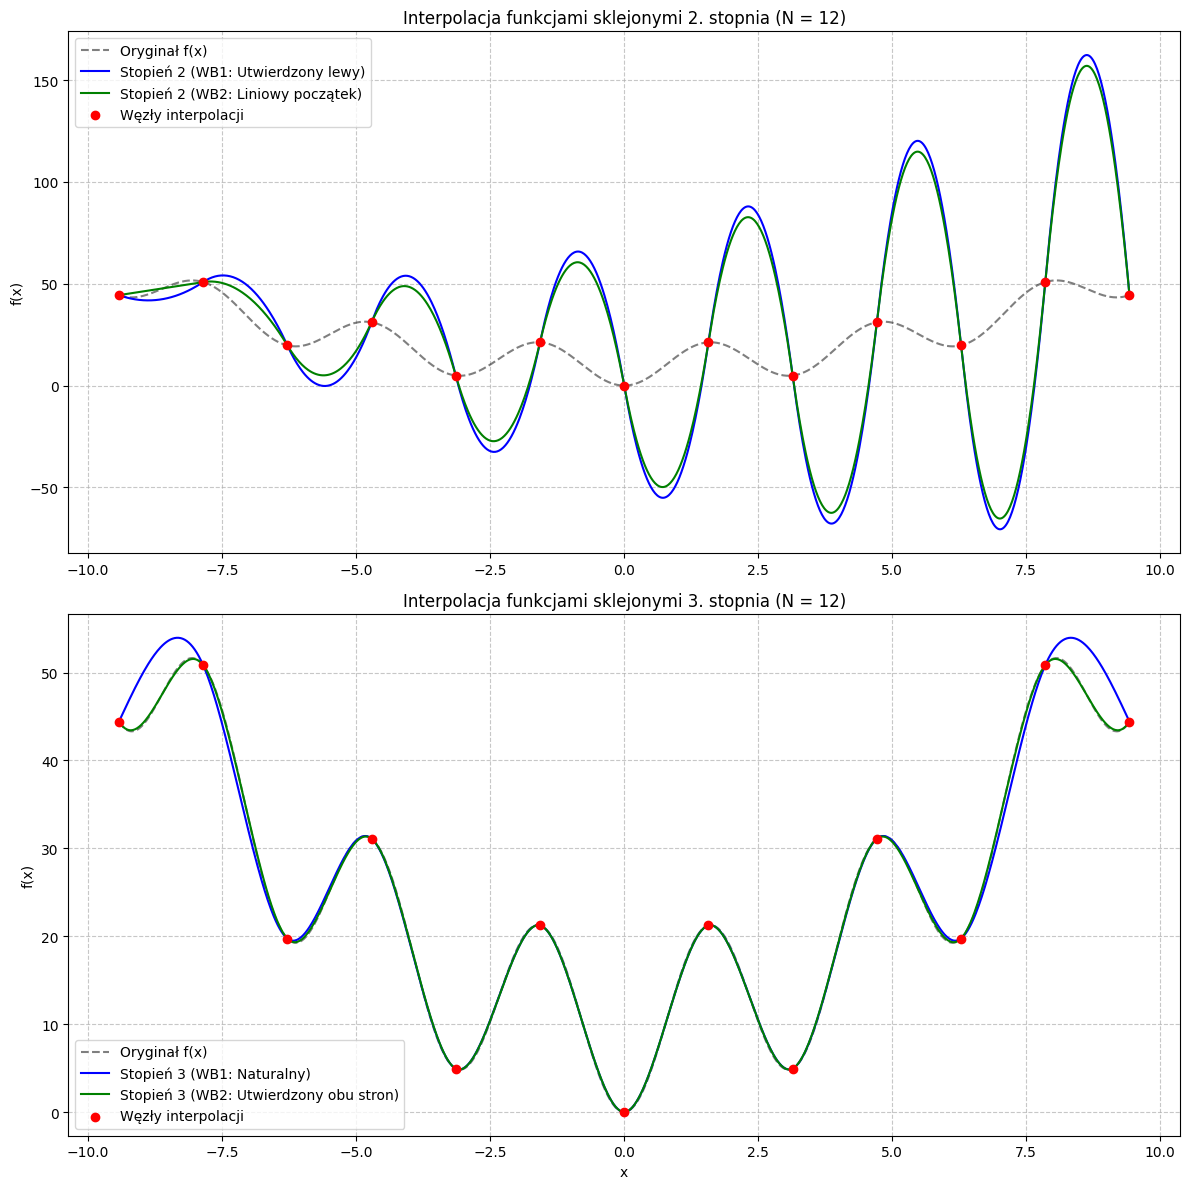

In [3]:
# Parametry siatki interpolacyjnej (mała liczba przedziałów do wizualizacji)
N_vis: int = 12 
x_nodes: np.ndarray = np.linspace(a, b, N_vis + 1)
y_nodes: np.ndarray = f(x_nodes)

# Wartości pochodnych na brzegach (dla warunków utwierdzonych)
df_a: float = df(a)
df_b: float = df(b)

# --- Inicjalizacja Splajnów ---
# Stopień 2
qs1 = QuadraticSpline(x_nodes, y_nodes, wb_type=1, df_x1=df_a) # WB1: Lewy utwierdzony
qs2 = QuadraticSpline(x_nodes, y_nodes, wb_type=2)             # WB2: Liniowy początek

# Stopień 3
cs1 = CubicSpline(x_nodes, y_nodes, wb_type=1)                               # WB1: Naturalny
cs2 = CubicSpline(x_nodes, y_nodes, wb_type=2, df_x1=df_a, df_xn=df_b)       # WB2: Utwierdzony

# --- Obliczanie wartości ---
y_qs1: np.ndarray = qs1.evaluate(x_dense)
y_qs2: np.ndarray = qs2.evaluate(x_dense)
y_cs1: np.ndarray = cs1.evaluate(x_dense)
y_cs2: np.ndarray = cs2.evaluate(x_dense)

# --- Wizualizacja ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Wykres 1: Splajny kwadratowe
ax1.plot(x_dense, y_true, 'k--', label="Oryginał f(x)", alpha=0.5)
ax1.plot(x_dense, y_qs1, 'b-', label="Stopień 2 (WB1: Utwierdzony lewy)")
ax1.plot(x_dense, y_qs2, 'g-', label="Stopień 2 (WB2: Liniowy początek)")
ax1.scatter(x_nodes, y_nodes, color='red', zorder=5, label="Węzły interpolacji")
ax1.set_title(f"Interpolacja funkcjami sklejonymi 2. stopnia (N = {N_vis})")
ax1.set_ylabel("f(x)")
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Wykres 2: Splajny sześcienne
ax2.plot(x_dense, y_true, 'k--', label="Oryginał f(x)", alpha=0.5)
ax2.plot(x_dense, y_cs1, 'b-', label="Stopień 3 (WB1: Naturalny)")
ax2.plot(x_dense, y_cs2, 'g-', label="Stopień 3 (WB2: Utwierdzony obu stron)")
ax2.scatter(x_nodes, y_nodes, color='red', zorder=5, label="Węzły interpolacji")
ax2.set_title(f"Interpolacja funkcjami sklejonymi 3. stopnia (N = {N_vis})")
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

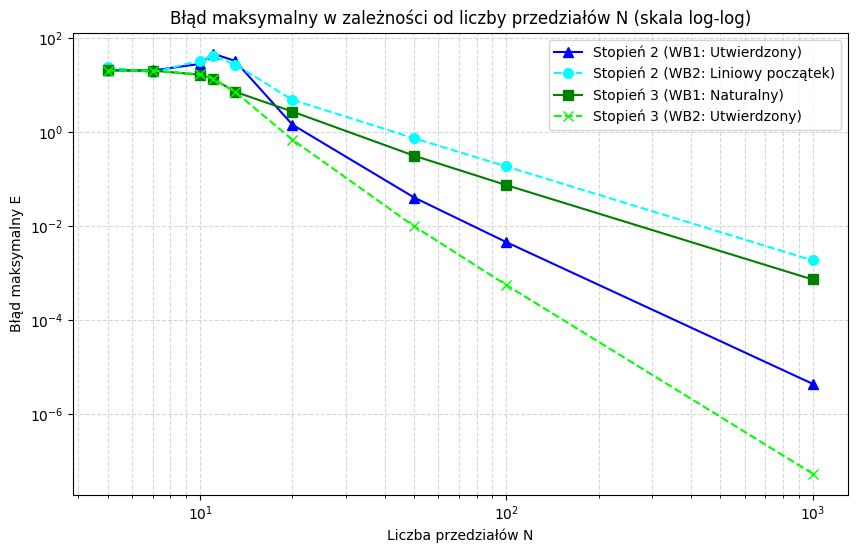

,Typ Splajnu,Liczba Węzłów (N+1),Liczba Przedziałów (N),Błąd Maksymalny,Błąd Średniokwadratowy
0,Stopień 2 (WB1: Utwierdzony),6,5,2.022535e+01,1.003629e+01
1,Stopień 2 (WB2: Liniowy początek),6,5,2.372933e+01,9.714294e+00
2,Stopień 3 (WB1: Naturalny),6,5,2.011749e+01,9.605088e+00
3,Stopień 3 (WB2: Utwierdzony),6,5,1.990586e+01,9.970525e+00
4,Stopień 2 (WB1: Utwierdzony),8,7,2.005435e+01,1.003669e+01
5,Stopień 2 (WB2: Liniowy początek),8,7,1.820669e+01,9.848573e+00
6,Stopień 3 (WB1: Naturalny),8,7,1.995146e+01,9.837666e+00
7,Stopień 3 (WB2: Utwierdzony),8,7,1.997938e+01,9.989717e+00
8,Stopień 2 (WB1: Utwierdzony),11,10,2.772539e+01,1.409409e+01
9,Stopień 2 (WB2: Liniowy początek),11,10,3.269206e+01,1.455324e+01


In [4]:
import pandas as pd

# --- 5. Badanie dokładności i zbieżności (Tabela i Wykresy) ---

# Badane liczby przedziałów (wybrane tak, by uchwycić ciekawe przypadki)
N_vals = [5, 7, 10, 11, 13, 20, 50, 100, 1000]

# Listy na zapisywanie wyników do tabeli
results = []

# Supergęsta siatka referencyjna do wyliczania błędu
x_eval = np.linspace(a, b, 5000)
y_eval_true = f(x_eval)

for N in N_vals:
    x_n = np.linspace(a, b, N + 1)
    y_n = f(x_n)
    
    df_a_n = df(a)
    df_b_n = df(b)
    
    # Inicjalizacja modeli
    models = {
        "Stopień 2 (WB1: Utwierdzony)": QuadraticSpline(x_n, y_n, wb_type=1, df_x1=df_a_n),
        "Stopień 2 (WB2: Liniowy początek)": QuadraticSpline(x_n, y_n, wb_type=2),
        "Stopień 3 (WB1: Naturalny)": CubicSpline(x_n, y_n, wb_type=1),
        "Stopień 3 (WB2: Utwierdzony)": CubicSpline(x_n, y_n, wb_type=2, df_x1=df_a_n, df_xn=df_b_n)
    }
    
    for name, model in models.items():
        y_pred = model.evaluate(x_eval)
        
        # Błąd maksymalny
        max_err = np.max(np.abs(y_eval_true - y_pred))
        
        # Błąd średniokwadratowy (RMSE)
        rmse_err = np.sqrt(np.mean((y_eval_true - y_pred)**2))
        
        results.append({
            "Typ Splajnu": name,
            "Liczba Węzłów (N+1)": N + 1,
            "Liczba Przedziałów (N)": N,
            "Błąd Maksymalny": max_err,
            "Błąd Średniokwadratowy": rmse_err
        })

# Tworzenie tabeli Pandas
df_results = pd.DataFrame(results)

# --- Wizualizacja Błędu (Log-Log) ---
plt.figure(figsize=(10, 6))
colors = ['b', 'cyan', 'g', 'lime']
markers = ['^-', 'o--', 's-', 'x--']

for idx, name in enumerate(models.keys()):
    subset = df_results[df_results["Typ Splajnu"] == name]
    plt.loglog(subset["Liczba Przedziałów (N)"], subset["Błąd Maksymalny"], 
               markers[idx], color=colors[idx], label=name, markersize=7)

plt.title("Błąd maksymalny w zależności od liczby przedziałów N (skala log-log)")
plt.xlabel("Liczba przedziałów N")
plt.ylabel("Błąd maksymalny E")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# Wyświetlenie tabeli
display(df_results)

## 6. Wnioski

Na podstawie przeprowadzonych badań oraz wygenerowanych wykresów można wyciągnąć następujące wnioski:

**1. Stabilność i propagacja błędu:**
Z wykresu dla małej liczby przedziałów (N=12) jednoznacznie wynika, że funkcje sklejane 2. stopnia (kwadratowe) są wysoce niestabilne dla funkcji silnie oscylujących. Wynika to ze sposobu wyliczania współczynników "od lewej do prawej" (propagacja błędu w przód). Z kolei funkcje sześcienne rozwiązują układ globalnie (macierz trójprzekątniowa), co skutecznie amortyzuje naprężenia i zapobiega "odklejaniu" się krzywej od wzorca na odległych przedziałach.

**2. Szybkość zbieżności (Wykres Log-Log):**
Analiza dokładności dowodzi znacznie wyższego rzędu zbieżności dla splajnów sześciennych. Wykresy w skali log-log mają postać opadających prostych, przy czym proste dla funkcji 3. stopnia opadają znacznie stromiej. Oznacza to, że dwukrotne zagęszczenie siatki węzłów zmniejsza błąd dla funkcji sześciennych drastycznie szybciej niż dla funkcji kwadratowych (co potwierdza teoretyczne dowody o błędzie interpolacji rzędu $O(h^4)$ dla sześciennych z warunkiem utwierdzonym).

**3. Rola warunków brzegowych:**
Wykresy dowodzą, że narzucenie dodatkowej informacji (np. dokładnej wartości pochodnej z warunku "utwierdzonego") znacząco poprawia jakość interpolacji na skrajach przedziału.
* W przypadku splajnów sześciennych, warunek utwierdzony (WB2) generuje zauważalnie mniejszy błąd maksymalny niż warunek naturalny (WB1), w którym krzywa "rozluźnia" się na krańcach przedziału.
* W przypadku splajnów kwadratowych, nieodpowiednio dobrany warunek początkowy powoduje złe oszacowanie pierwszej paraboli, co ze względu na ciągłość pierwszej pochodnej rzutuje na całkowicie błędny kształt krzywej na prawym końcu badanego obszaru.

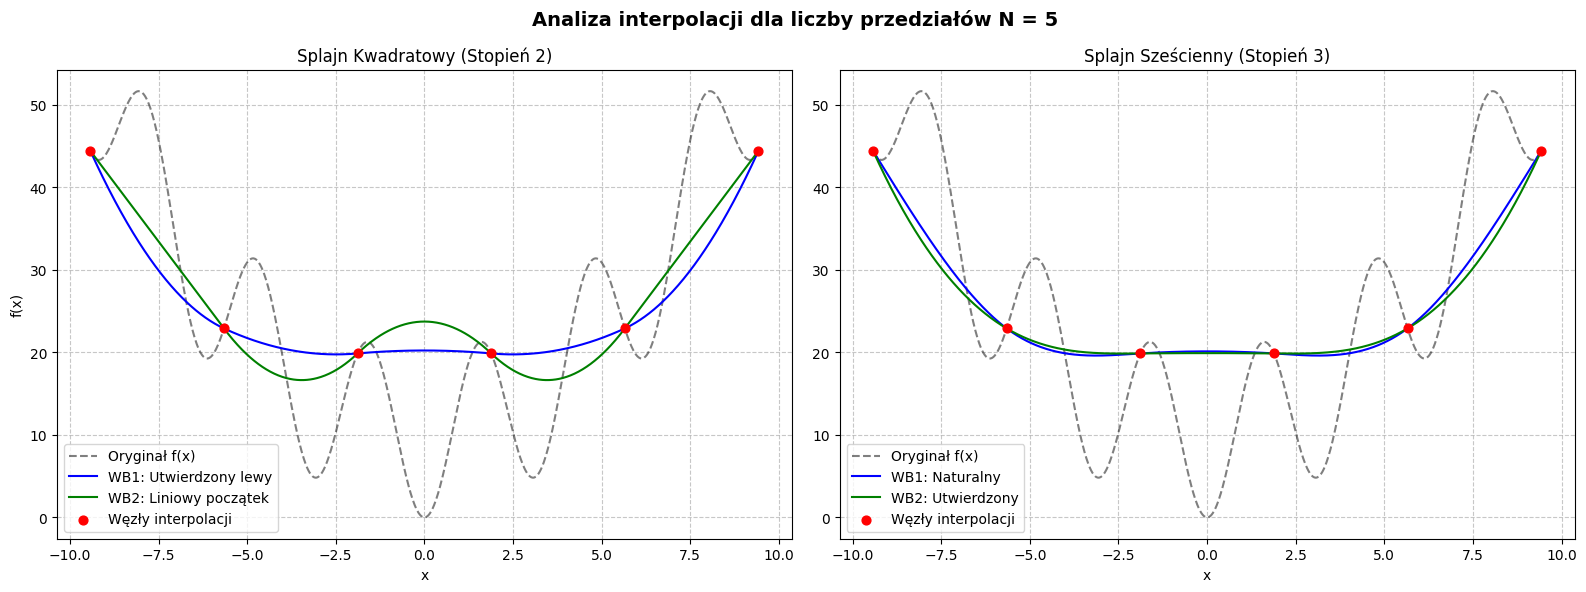

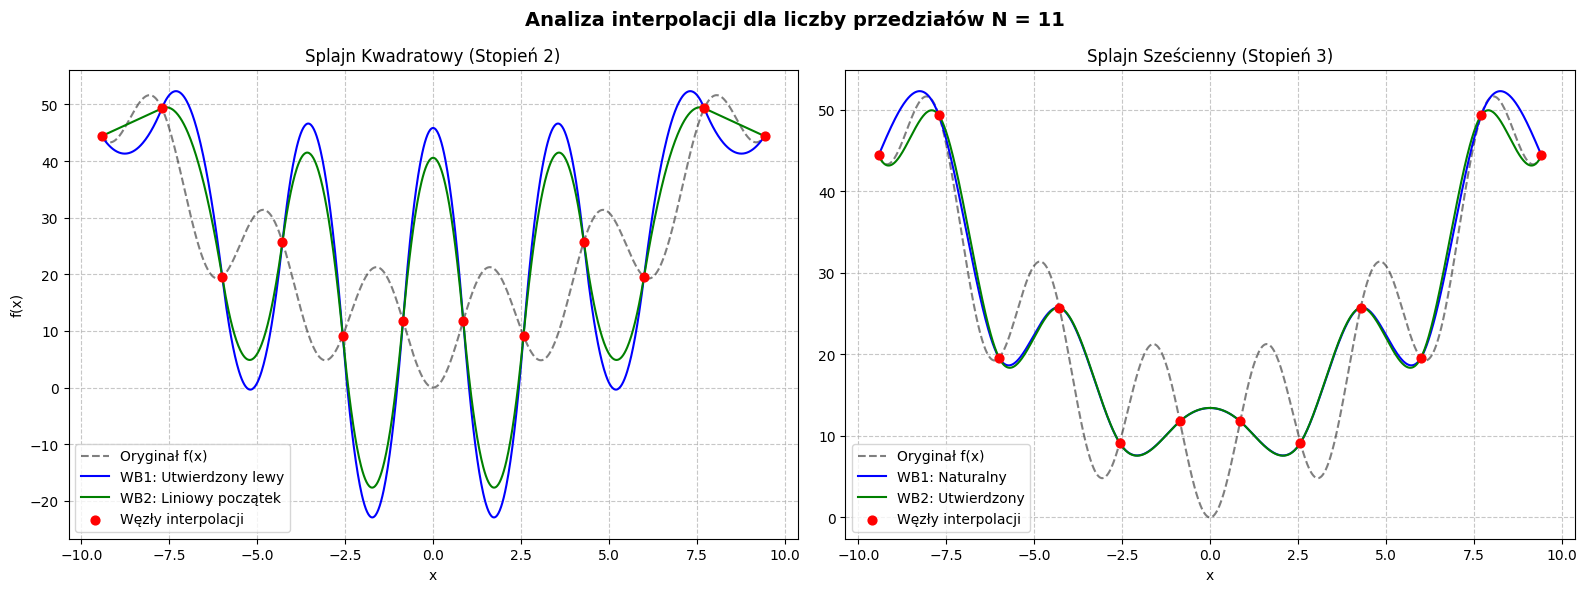

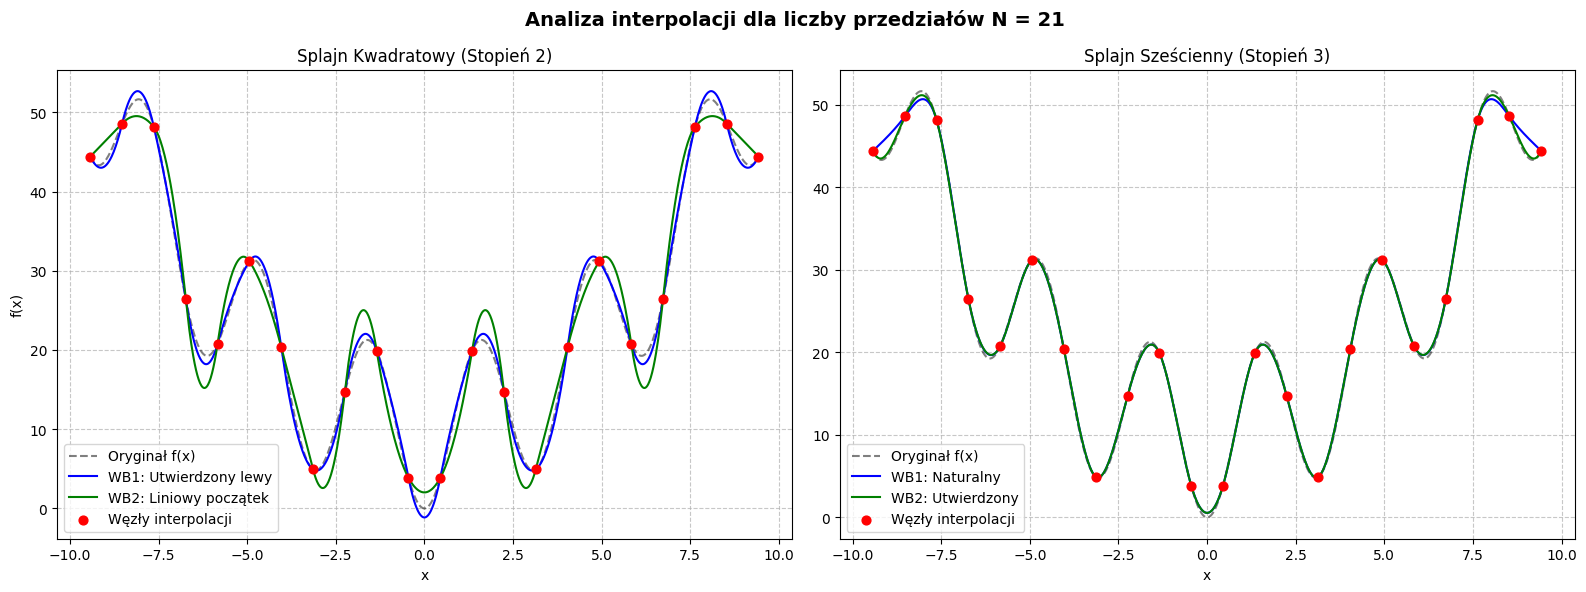

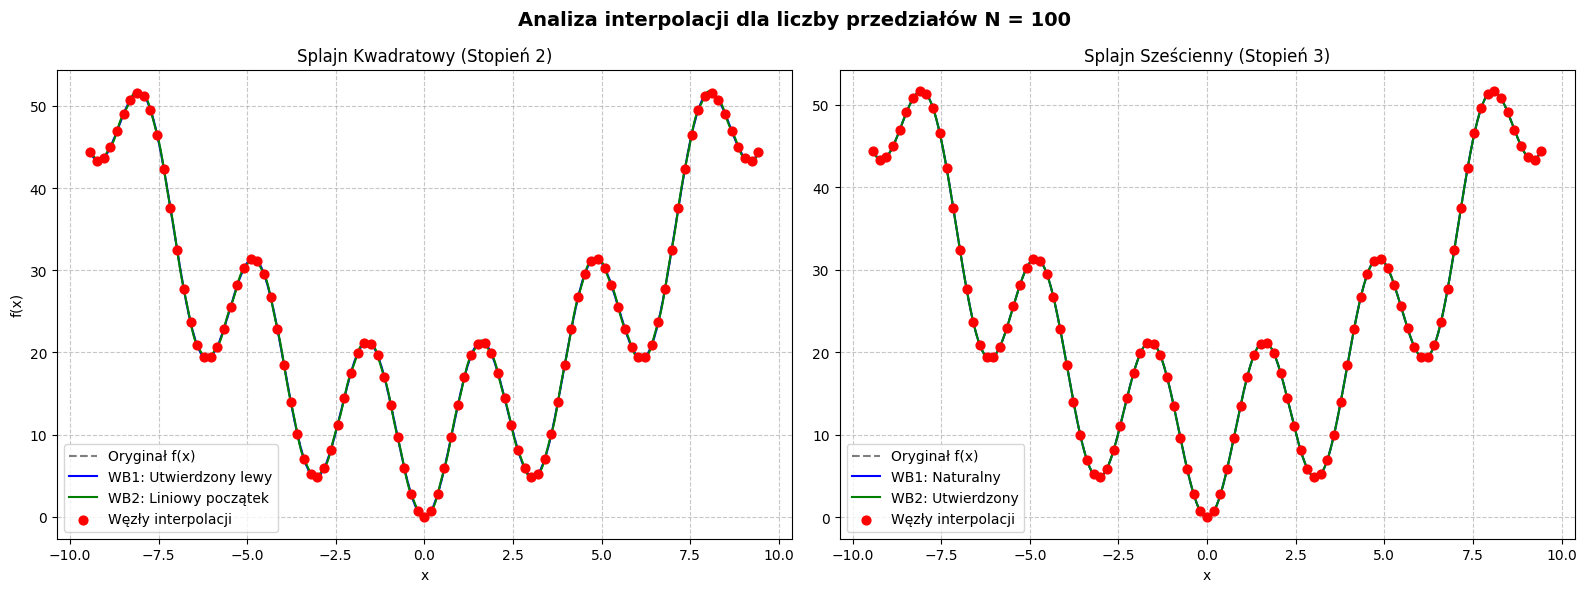

In [5]:
# --- 6. Generowanie wykresów dla interesujących przypadków ---

# Lista przypadków do szczegółowej analizy wizualnej
N_cases = [5, 11, 21, 100]

for N in N_cases:
    # 1. Przygotowanie węzłów
    x_n = np.linspace(a, b, N + 1)
    y_n = f(x_n)
    
    # 2. Obliczenie wartości analitycznych pochodnych na brzegach
    df_a_n = df(a)
    df_b_n = df(b)
    
    # 3. Utworzenie modeli
    qs1 = QuadraticSpline(x_n, y_n, wb_type=1, df_x1=df_a_n)
    qs2 = QuadraticSpline(x_n, y_n, wb_type=2)
    
    cs1 = CubicSpline(x_n, y_n, wb_type=1)
    cs2 = CubicSpline(x_n, y_n, wb_type=2, df_x1=df_a_n, df_xn=df_b_n)
    
    # 4. Obliczenie gęstych wektorów do rysowania
    y_qs1 = qs1.evaluate(x_dense)
    y_qs2 = qs2.evaluate(x_dense)
    y_cs1 = cs1.evaluate(x_dense)
    y_cs2 = cs2.evaluate(x_dense)
    
    # 5. Konfiguracja układu wykresów (1 wiersz, 2 kolumny)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Lewy wykres: Stopień 2
    ax1.plot(x_dense, y_true, 'k--', label="Oryginał f(x)", alpha=0.5)
    ax1.plot(x_dense, y_qs1, 'b-', label="WB1: Utwierdzony lewy", linewidth=1.5)
    ax1.plot(x_dense, y_qs2, 'g-', label="WB2: Liniowy początek", linewidth=1.5)
    ax1.scatter(x_n, y_n, color='red', zorder=5, label="Węzły interpolacji", s=40)
    ax1.set_title(f"Splajn Kwadratowy (Stopień 2)", fontsize=12)
    ax1.set_xlabel("x")
    ax1.set_ylabel("f(x)")
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    # Prawy wykres: Stopień 3
    ax2.plot(x_dense, y_true, 'k--', label="Oryginał f(x)", alpha=0.5)
    ax2.plot(x_dense, y_cs1, 'b-', label="WB1: Naturalny", linewidth=1.5)
    ax2.plot(x_dense, y_cs2, 'g-', label="WB2: Utwierdzony", linewidth=1.5)
    ax2.scatter(x_n, y_n, color='red', zorder=5, label="Węzły interpolacji", s=40)
    ax2.set_title(f"Splajn Sześcienny (Stopień 3)", fontsize=12)
    ax2.set_xlabel("x")
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    
    # Dodanie głównego tytułu dla całej figury
    plt.suptitle(f"Analiza interpolacji dla liczby przedziałów N = {N}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Wyświetlenie wygenerowanego obrazka
    plt.show()